In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD DATA

export = pd.read_csv("export.csv")
indices = pd.read_csv("indices_parcelles_2024-01-01_2024-12-31_win5d.csv")

print(export.head())
print(indices.head())

# 2. MERGE

df = indices.merge(export, on="ID_PARCEL")

print(df.shape)
print(df.columns)

     fid  ID_PARCEL  SURF_PARC CODE_CULTU  CODE_GROUP CULTURE_D1 CULTURE_D2
0   6367    7243144     285.16        SPL          17        NaN        NaN
1  61818       1653       5.82        VRC          21        NaN        NaN
2  62096      20221       0.24        VRC          21        NaN        NaN
3  62109      21403       0.50        SNE          28        NaN        NaN
4  62110      21404       0.85        OLI          23        NaN        NaN
         date   tile  ID_PARCEL index  value_mean  px_count  cloud_scene
0  2024-01-04  31TEJ     125464  NDVI    0.136674        38     8.786535
1  2024-01-04  31TEJ     125464  NDMI   -0.149129        38     8.786535
2  2024-01-04  31TEJ     125464  NDWI   -0.196797        38     8.786535
3  2024-01-04  31TEJ     125464   EVI    0.452529        38     8.786535
4  2024-01-04  31TEJ     340824  NDVI    0.294348       251     8.786535
(11327228, 13)
Index(['date', 'tile', 'ID_PARCEL', 'index', 'value_mean', 'px_count',
       'cloud_scene'

In [ ]:
print

In [13]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,ID_PARCEL,value_mean,px_count,cloud_scene,fid,SURF_PARC,CODE_GROUP
count,1.132723e+07,1.132723e+07,1.132723e+07,1.132723e+07,1.132723e+07,1.132723e+07,1.132723e+07
mean,5.944172e+06,2.868381e+03,1.740473e+02,1.467378e+01,8.926705e+05,1.890236e+00,1.993413e+01
std,3.356086e+06,5.080609e+05,7.330596e+02,1.250870e+01,9.977846e+04,8.382333e+00,5.745318e+00
min,1.600000e+01,-3.875007e+06,1.000000e+01,2.532000e-03,6.367000e+03,2.000000e-02,1.000000e+00
25%,3.012288e+06,-1.690436e-01,3.500000e+01,1.395652e+00,8.640280e+05,3.700000e-01,1.800000e+01
50%,6.033969e+06,1.663143e-01,7.400000e+01,1.426897e+01,9.026310e+05,7.600000e-01,2.100000e+01
75%,9.020918e+06,4.705647e-01,1.460000e+02,2.323813e+01,9.413480e+05,1.520000e+00,2.100000e+01
max,1.160082e+07,3.745000e+08,7.082500e+04,3.836267e+01,1.601817e+06,7.091300e+02,2.800000e+01


In [16]:
print("Value counts for 'CODE_CULTU':")
display(df['CODE_CULTU'].value_counts().head())

Value counts for 'CODE_CULTU':


,count
CODE_CULTU,
VRC,5528668
BOR,857900
SNE,824456
JAC,674920
PPH,673684


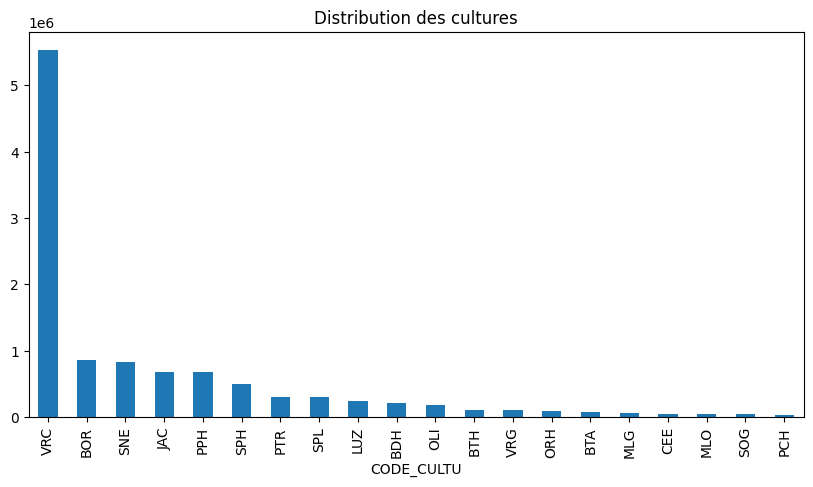

In [ ]:
plt.figure(figsize=(10,5))
df["CODE_CULTU"].value_counts().head(20).plot(kind="bar")
plt.title("Distribution des cultures")
plt.show()

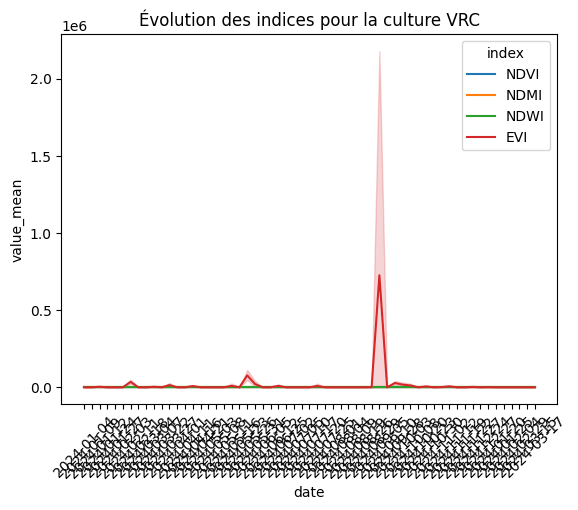

In [9]:
sample = df[df["CODE_CULTU"] == "VRC"]

sns.lineplot(data=sample, x="date", y="value_mean", hue="index")
plt.title("Évolution des indices pour la culture VRC")
plt.xticks(rotation=45)
plt.show()

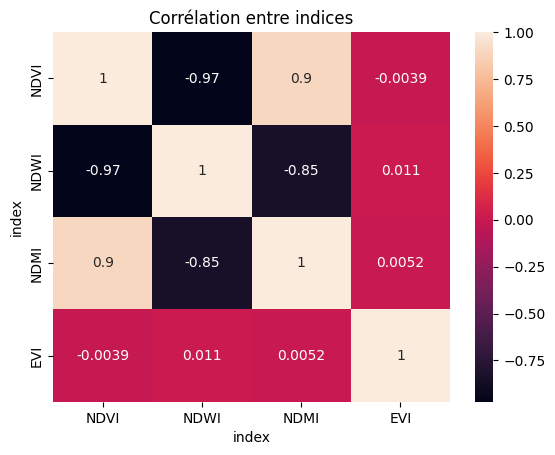

In [12]:
df_pivot = df.pivot_table(
    index=["ID_PARCEL", "date"],
    columns="index",
    values="value_mean"
)

df_pivot = df_pivot.reset_index()
corr = df_pivot[["NDVI", "NDWI", "NDMI", "EVI"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Corrélation entre indices")
plt.show()